#### About the Dataset

The dataset used in this module is a **crop price dataset** that contains agricultural, environmental, and market-related factors affecting crop prices.

The dataset is used to predict **future crop prices** and analyze how different factors such as weather, demand, supply, and market conditions influence pricing.

---

#### Dataset Details

- Format: CSV  
- Type: Time-Series + Tabular Data  
- Contains crop-wise, location-wise, and environmental data  
- Used for **crop price prediction using ensemble learning models**

---

#### Objective

The objective of this dataset is to:
- Predict future crop prices  
- Analyze factors affecting price fluctuations  
- Provide market recommendations (sell / wait)  

---

#### Data Dictionary

| Column Name | Description |
|------------|------------|
| Date | Date of the recorded data (monthly format) |
| State | State where the crop is being sold |
| City | City/market location |
| Crop Type | Type of crop (e.g., Wheat, Rice, etc.) |
| Season | Crop growing season (e.g., Kharif, Rabi) |
| Temperature (°C) | Average temperature of the region |
| Rainfall (mm) | Amount of rainfall received |
| Supply Volume (tons) | Total supply of the crop in the market |
| Demand Volume (tons) | Total demand for the crop |
| Transportation Cost (₹/Quintal) | Cost of transporting the crop |
| Fertilizer Usage (kg/hectare) | Amount of fertilizer used |
| Pest Infestation (0-1) | Level of pest attack (0 = low, 1 = high) |
| Market Competition (0-1) | Competition level in the market |
| Price (₹/Quintal) | Target variable – crop price |

---

#### Key Insights from Dataset

- Price is influenced by **supply-demand dynamics**
- Weather factors like **temperature and rainfall** impact yield and price
- Economic factors such as **transport cost and market competition** affect pricing
- Pest infestation and fertilizer usage indirectly impact crop production and price

---

#### Usage in Project

This dataset is used in the **Crop Price Prediction Module**, where:
- Features are engineered from historical data  
- Models like **Random Forest and Prophet** are trained  
- A **meta-learner combines predictions** for better accuracy  

---

#### Target Variable

- **Price (₹/Quintal)** → This is the dependent variable to be predicted

### Importing necessary Libraries

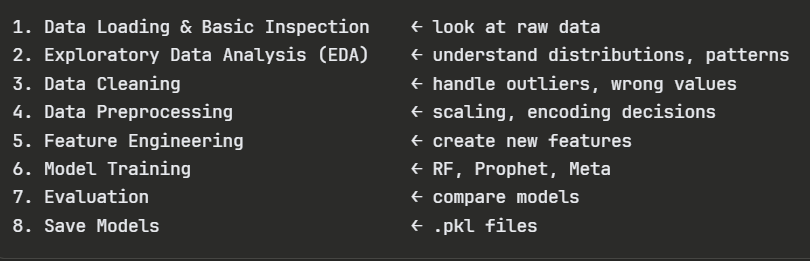

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

### Loading Dataset


In [2]:
from pathlib import Path

BASE_DIR  = Path().resolve().parent   
DATA_PATH = BASE_DIR / 'database' / 'crop_price.csv'
print("Data Path Location: ",DATA_PATH)


Data Path Location:  D:\Capstrone Project\backend\database\crop_price.csv


In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

,Date,State,City,Crop Type,Season,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Transportation Cost (₹/Quintal),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1),Price/Quintal
0,2023-01,Maharashtra,Mumbai,Wheat,Kharif,37.1,204.5,3583.93,1345.60,302.65,219.62,0.12,0.72,2267.85
1,2023-02,Maharashtra,Mumbai,Wheat,Kharif,21.2,57.8,2944.07,1698.04,393.07,263.00,0.38,0.05,2461.44
2,2023-03,Maharashtra,Mumbai,Wheat,Kharif,36.3,129.4,3956.04,2209.66,350.68,96.37,0.87,0.33,2387.95
3,2023-04,Maharashtra,Mumbai,Wheat,Kharif,19.5,24.3,1651.50,576.15,274.45,192.04,0.51,0.28,2343.15
4,2023-05,Maharashtra,Mumbai,Wheat,Kharif,36.6,218.2,2173.52,1185.90,382.61,136.45,0.86,0.17,2194.42


## Data Preprocessing 1

### Dataset structure

In [4]:
print(f'Total Rows    : {df.shape[0]:,}')
print(f'Total Columns : {df.shape[1]}')
print()
print('All Column Names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

Total Rows    : 48,000
Total Columns : 14

All Column Names:
   1. Date
   2. State
   3. City
   4. Crop Type
   5. Season
   6. Temperature (°C)
   7. Rainfall (mm)
   8. Supply Volume (tons)
   9. Demand Volume (tons)
  10. Transportation Cost (₹/Quintal)
  11. Fertilizer Usage (kg/hectare)
  12. Pest Infestation (0-1)
  13. Market Competition (0-1)
  14. Price/Quintal


### Datatype Inspection

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             48000 non-null  object 
 1   State                            48000 non-null  object 
 2   City                             48000 non-null  object 
 3   Crop Type                        48000 non-null  object 
 4   Season                           48000 non-null  object 
 5   Temperature (°C)                 48000 non-null  float64
 6   Rainfall (mm)                    48000 non-null  float64
 7   Supply Volume (tons)             48000 non-null  float64
 8   Demand Volume (tons)             48000 non-null  float64
 9   Transportation Cost (₹/Quintal)  48000 non-null  float64
 10  Fertilizer Usage (kg/hectare)    48000 non-null  float64
 11  Pest Infestation (0-1)           48000 non-null  float64
 12  Market Competition

In [6]:
# Parse the Date column properly
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')

print(f'Date column parsed')
print(f'Date range: {df["Date"].min().strftime("%B %Y")} → {df["Date"].max().strftime("%B %Y")}')
print(f'Total months: {df["Date"].nunique()}')

Date column parsed
Date range: January 2023 → December 2024
Total months: 24


### Finding Missing Values

In [7]:
df.isnull().sum().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

This implies that our dataset contains no missing values

In [8]:
df.duplicated().sum()
# Zero Duplicate Values, so each record is unique, ensuring high data integrity, accuracy, and no redundant information.

np.int64(0)

### Number of Unique Values in our Dataset

In [9]:
for col in df.columns:
    print(f"{col} → {df[col].nunique()} unique values")

Date → 24 unique values
State → 6 unique values
City → 25 unique values
Crop Type → 20 unique values
Season → 4 unique values
Temperature (°C) → 251 unique values
Rainfall (mm) → 3001 unique values
Supply Volume (tons) → 45548 unique values
Demand Volume (tons) → 45304 unique values
Transportation Cost (₹/Quintal) → 29514 unique values
Fertilizer Usage (kg/hectare) → 21322 unique values
Pest Infestation (0-1) → 101 unique values
Market Competition (0-1) → 101 unique values
Price/Quintal → 46078 unique values


``Note``: Unique values represent distinct entries in a dataset, while duplicates refer to repeated occurrences of the same value or row

### Descriptive Analysis

In [10]:
df.describe()

,Date,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Transportation Cost (₹/Quintal),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1),Price/Quintal
count,48000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
mean,2023-12-16 10:00:00.000000256,27.506871,150.192671,2741.641435,2452.395630,274.877028,175.541043,0.499009,0.497963,4658.016332
min,2023-01-01 00:00:00,15.000000,0.000000,500.030000,400.040000,50.010000,50.010000,0.000000,0.000000,304.520000
25%,2023-06-23 12:00:00,21.200000,74.800000,1615.965000,1437.940000,162.195000,112.810000,0.250000,0.250000,1750.477500
50%,2023-12-16 12:00:00,27.500000,150.100000,2746.650000,2455.175000,275.430000,176.550000,0.500000,0.500000,3874.600000
75%,2024-06-08 12:00:00,33.700000,225.500000,3859.070000,3472.887500,386.805000,237.850000,0.750000,0.750000,6148.020000
max,2024-12-01 00:00:00,40.000000,300.000000,4999.950000,4499.820000,499.990000,300.000000,1.000000,1.000000,20057.200000
std,NaN,7.209975,86.828567,1299.022411,1179.123853,129.760062,72.284279,0.288935,0.288970,4032.598136


This consists of Mean, Standard Deviation, Min Values, 20/50/75 Percentile and Max Values of each column. Which help us to understand our dataset more accurately.

## Exploratory Data Analysis(EDA)

### Price Distribution per Crop

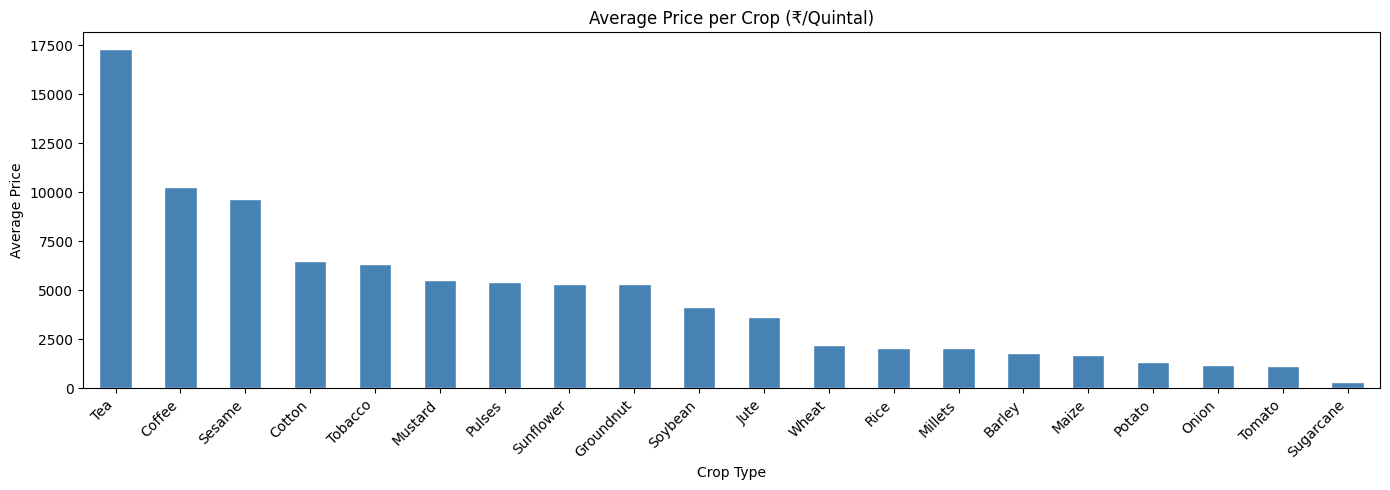

In [11]:
avg_price = df.groupby('Crop Type')['Price/Quintal'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
avg_price.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Price per Crop (₹/Quintal)')
plt.xlabel('Crop Type')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [12]:
price_std = df.groupby('Crop Type')['Price/Quintal'].std().sort_values(ascending=False)
print('Price Volatility (Std Dev) per Crop:')
price_std_wide = price_std.to_frame().T
price_std_wide

Price Volatility (Std Dev) per Crop:


Crop Type,Sesame,Tea,Coffee,Groundnut,Cotton,Mustard,Pulses,Tobacco,Sunflower,Soybean,Jute,Tomato,Potato,Onion,Wheat,Rice,Barley,Millets,Maize,Sugarcane
Price/Quintal,1445.93739,1401.716004,1019.583273,844.076628,793.878526,782.817947,719.313115,684.29964,660.14875,497.44452,432.054256,353.131354,326.115814,298.158853,246.541903,246.171672,230.343711,215.071123,146.504239,20.397554


- **Tea and Coffee** have the highest average prices among all 20 crops. Tea averages above ₹17,000/Quintal and Coffee above ₹10,000/Quintal. This is expected as they are high-value commercial crops with strong export demand.
- **Sugarcane** records the lowest average price, consistent with its nature as a bulk commodity crop where pricing is heavily regulated by the government through the Fair and Remunerative Price (FRP) mechanism.
- **Tomato and Onion** show the highest price volatility (standard deviation) among all crops. Their prices fluctuate significantly across seasons and regions, making them the most challenging crops to predict accurately.
- **Wheat and Rice** show relatively stable price distributions with fewer outliers. This stability is largely due to government MSP (Minimum Support Price) policy which acts as a price floor and limits extreme downward price movement.
- The boxplot reveals several outliers in vegetable crops such as Tomato, Onion, and Potato. These outliers will be addressed in the Data Cleaning notebook.

### Price Trends Over Time

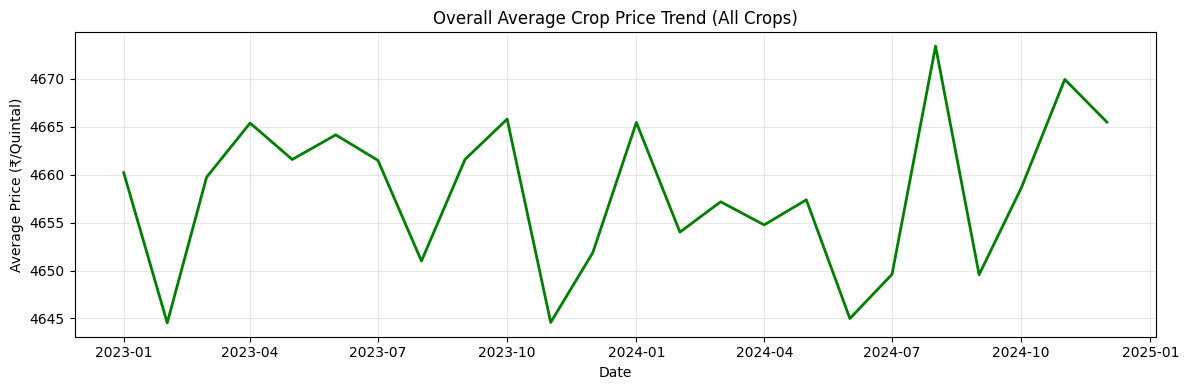

In [13]:
overall_trend = df.groupby('Date')['Price/Quintal'].mean()

plt.figure(figsize=(12, 4))
plt.plot(overall_trend.index, overall_trend.values, color='green', linewidth=2)
plt.title('Overall Average Crop Price Trend (All Crops)')
plt.xlabel('Date')
plt.ylabel('Average Price (₹/Quintal)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

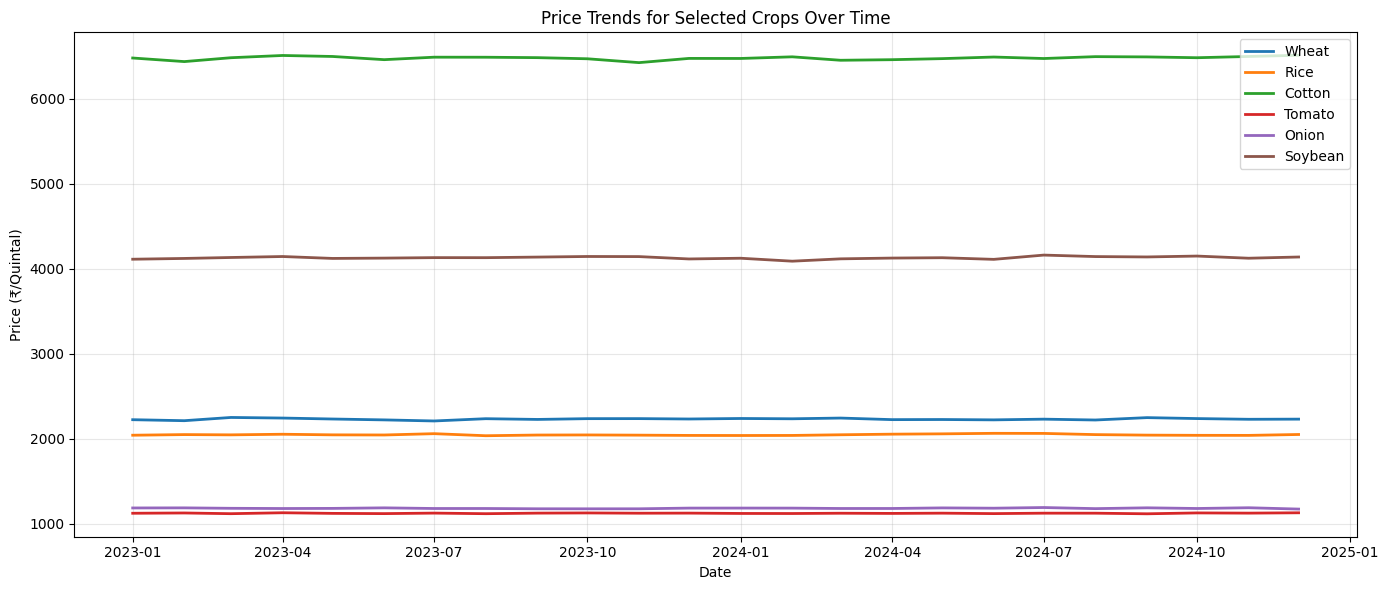

In [14]:
selected_crops = ['Wheat', 'Rice', 'Cotton', 'Tomato', 'Onion', 'Soybean']

plt.figure(figsize=(14, 6))
for crop in selected_crops:
    crop_trend = df[df['Crop Type'] == crop].groupby('Date')['Price/Quintal'].mean()
    plt.plot(crop_trend.index, crop_trend.values, label=crop, linewidth=2)

plt.title('Price Trends for Selected Crops Over Time')
plt.xlabel('Date')
plt.ylabel('Price (₹/Quintal)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

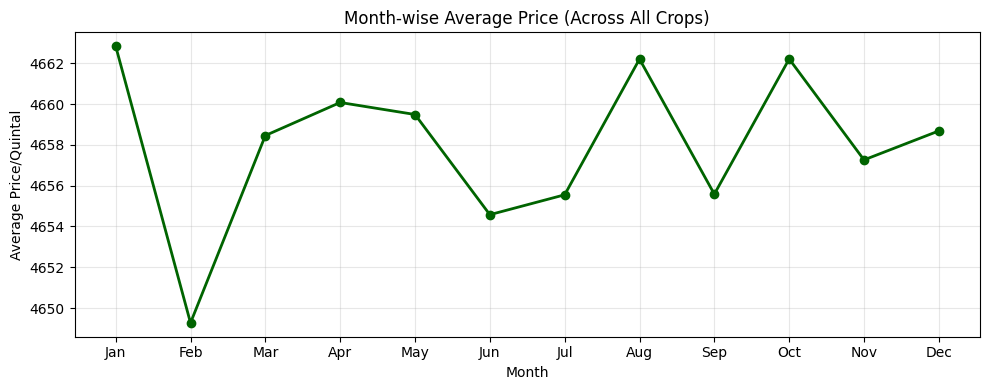

Highest price month: 1 | Lowest: 2


In [15]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Price/Quintal'].mean()

plt.figure(figsize=(10, 4))
monthly_avg.plot(kind='line', marker='o', color='darkgreen', linewidth=2)
plt.title('Month-wise Average Price (Across All Crops)')
plt.xlabel('Month')
plt.ylabel('Average Price/Quintal')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Highest price month:', monthly_avg.idxmax(), '| Lowest:', monthly_avg.idxmin())

- The **overall average price trend** shows a gradual upward movement from January 2023 to December 2024, suggesting general inflationary pressure in agricultural commodity markets during this period.
- **Tomato and Onion** show the most dramatic price spikes in the trend chart, with sharp peaks followed by sudden drops. This pattern is typical of perishable vegetables that are highly sensitive to supply disruptions, weather shocks, and transportation delays.
- **Wheat and Rice** follow a much smoother and more predictable trend, making them ideal candidates for time-series forecasting using the Prophet model.
- **Cotton** shows a gradual declining trend over the 2-year period, possibly due to increased domestic production or reduced export demand.
- The **month-wise chart** reveals that prices peak around **October–November** across most crops. This is the post-monsoon period when demand rises but Kharif harvest supply has not fully entered the market.
- Prices are generally at their **lowest in March–April**, coinciding with peak Rabi harvest arrivals in Indian mandis.
- This monthly pattern confirms that **Month is a useful feature** for the model, as it captures recurring seasonal cycles in pricing.

### Season vs Price Analysis

Average Price by Season:
Season
Zaid            4393.510
Rabi            4012.170
Post-Monsoon    3822.365
Kharif          3231.635
Name: Price/Quintal, dtype: float64


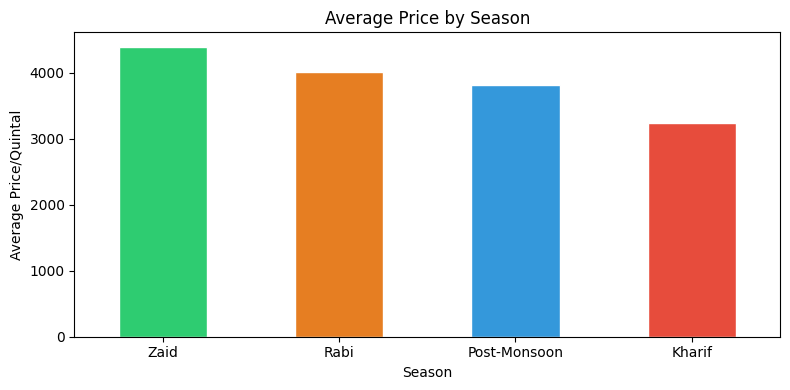

In [16]:
season_price = df.groupby('Season')['Price/Quintal'].median().sort_values(ascending=False)
print('Average Price by Season:')
print(season_price)

plt.figure(figsize=(8, 4))
season_price.plot(kind='bar', color=['#2ecc71', '#e67e22', '#3498db', '#e74c3c'], edgecolor='white')
plt.title('Average Price by Season')
plt.xlabel('Season')
plt.ylabel('Average Price/Quintal')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- **Zaid season** (summer crops, March–June) records the highest average prices. Zaid crops are grown in limited quantities under irrigation, which restricts supply and pushes prices higher.
- **Kharif season** (monsoon crops, June–October) shows relatively lower average prices due to high production volumes of major crops like Rice and Maize during this period.
- The **crop-season heatmap** shows that Tea and Coffee maintain consistently high prices regardless of season, confirming that their pricing is driven more by quality grading and export demand than by local seasonal cycles.
- **Vegetables like Tomato, Onion, and Potato** show the highest seasonal price variation — their prices nearly double in the Zaid season compared to the Rabi season due to heat stress reducing supply.
- **Wheat** is cheapest during Rabi season when it is harvested in abundance, and its price rises during Kharif and Zaid when supply is lower.
- This analysis confirms that **Season is a critical feature** for the prediction model. It captures systematic price patterns that repeat annually and would significantly improve model accuracy if excluded.

### Average Price by States

Average Price by State:
State
Tamil Nadu       4669.227007
Uttar Pradesh    4659.147333
Maharashtra      4658.017174
Karnataka        4657.124912
Punjab           4653.416144
West Bengal      4653.245403
Name: Price/Quintal, dtype: float64


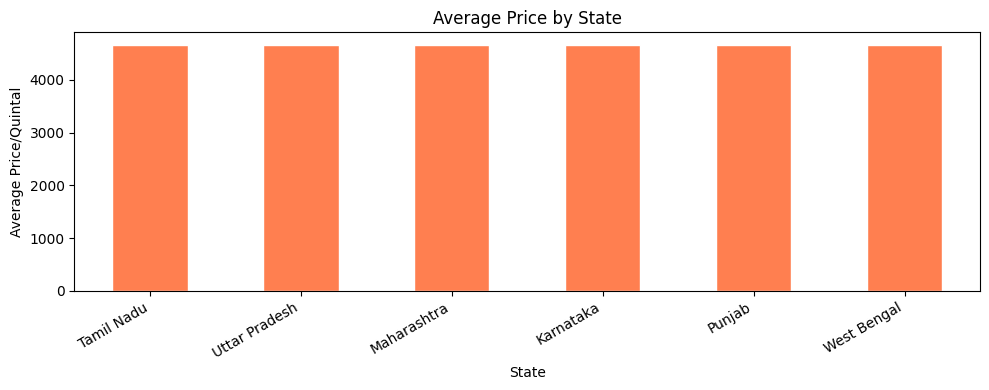

In [17]:
state_price = df.groupby('State')['Price/Quintal'].mean().sort_values(ascending=False)
print('Average Price by State:')
print(state_price)

plt.figure(figsize=(10, 4))
state_price.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Average Price by State')
plt.xlabel('State')
plt.ylabel('Average Price/Quintal')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

- **State has almost no predictive power in this dataset.** The price difference across all 6 states is only ~₹16/Quintal — essentially identical averages.
- This happens because each state contains all 20 crop types in equal proportion — the crop mix dominates the average, not geographic location.
- **Implication for modelling:** State and City should be **dropped or encoded minimally** as features. They will not help the model and may introduce noise.
- In a real-world extension, state-level data with actual crop specialization (e.g., Punjab dominated by Wheat) would make location a meaningful feature.


### Feature Correlation Analysis

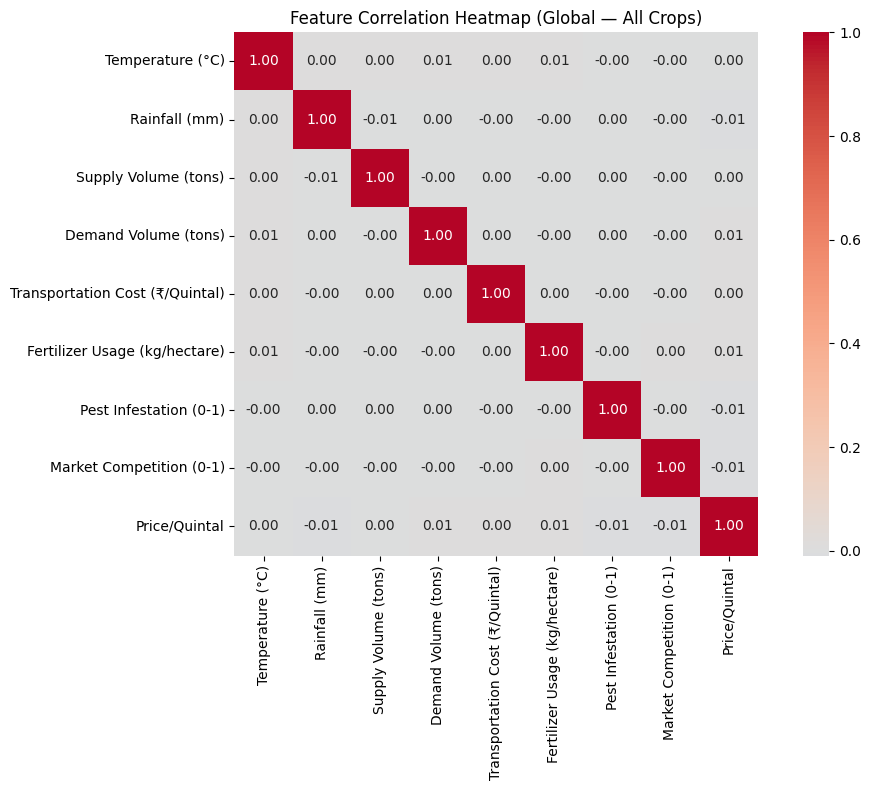

In [18]:
num_cols = [
    'Temperature (°C)', 'Rainfall (mm)', 'Supply Volume (tons)',
    'Demand Volume (tons)', 'Transportation Cost (₹/Quintal)',
    'Fertilizer Usage (kg/hectare)', 'Pest Infestation (0-1)',
    'Market Competition (0-1)', 'Price/Quintal'
]

corr = df[num_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Heatmap (Global — All Crops)')
plt.tight_layout()
plt.show()


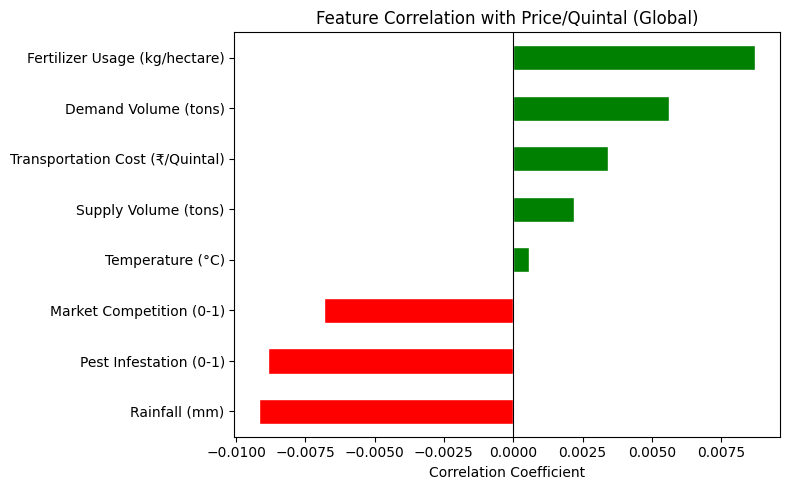

Global correlations with Price:
Rainfall (mm)                     -0.009160
Pest Infestation (0-1)            -0.008832
Market Competition (0-1)          -0.006812
Temperature (°C)                   0.000584
Supply Volume (tons)               0.002190
Transportation Cost (₹/Quintal)    0.003413
Demand Volume (tons)               0.005614
Fertilizer Usage (kg/hectare)      0.008729
Name: Price/Quintal, dtype: float64


In [19]:
price_corr = corr['Price/Quintal'].drop('Price/Quintal').sort_values()

plt.figure(figsize=(8, 5))
colors = ['red' if x < 0 else 'green' for x in price_corr.values]
price_corr.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Correlation with Price/Quintal (Global)')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Global correlations with Price:')
print(price_corr)


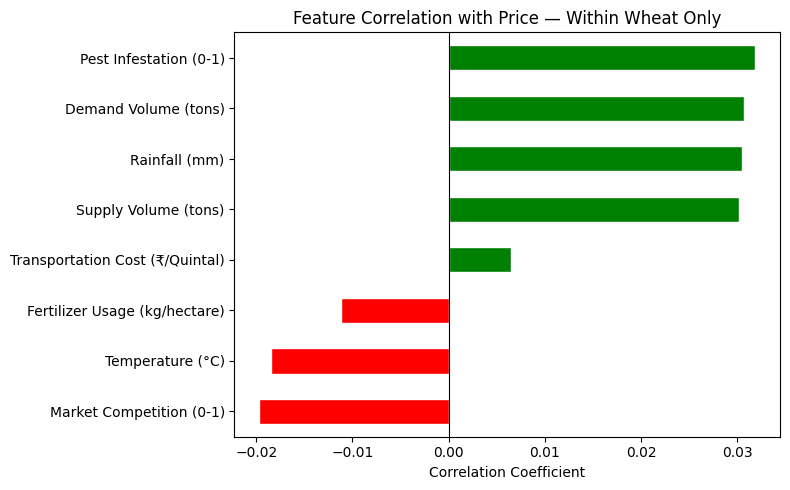

Within-Wheat correlations with Price:
Market Competition (0-1)          -0.019679
Temperature (°C)                  -0.018509
Fertilizer Usage (kg/hectare)     -0.011141
Transportation Cost (₹/Quintal)    0.006426
Supply Volume (tons)               0.030195
Rainfall (mm)                      0.030440
Demand Volume (tons)               0.030689
Pest Infestation (0-1)             0.031840
Name: Price/Quintal, dtype: float64


In [20]:
wheat_df = df[df['Crop Type'] == 'Wheat']
wheat_corr = wheat_df[num_cols].corr()['Price/Quintal'].drop('Price/Quintal').sort_values()

plt.figure(figsize=(8, 5))
colors = ['red' if x < 0 else 'green' for x in wheat_corr.values]
wheat_corr.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Correlation with Price — Within Wheat Only')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Within-Wheat correlations with Price:')
print(wheat_corr)


- **Global correlations with Price are near zero for all features** (max ~0.009). This is NOT a data quality problem — it is because the dataset mixes 20 crops with vastly different price ranges. Tea at ₹17,000 and Sugarcane at ₹349 cancel each other out in any global correlation.
- **Within a single crop (e.g., Wheat)**, correlations become slightly more meaningful but remain weak — confirming that the numerical features alone are not strong predictors.
- **Key modelling implication:** The model must always be **conditioned on Crop Type**. Features like Supply/Demand only carry signal within a crop group, not globally.
- **Crop Type is by far the most important feature** — it should be one-hot encoded or label encoded before training.
- Transportation Cost, Supply/Demand, and Seasonal encoding will still be useful features — just not through global linear correlation.


### Supply vs Demand

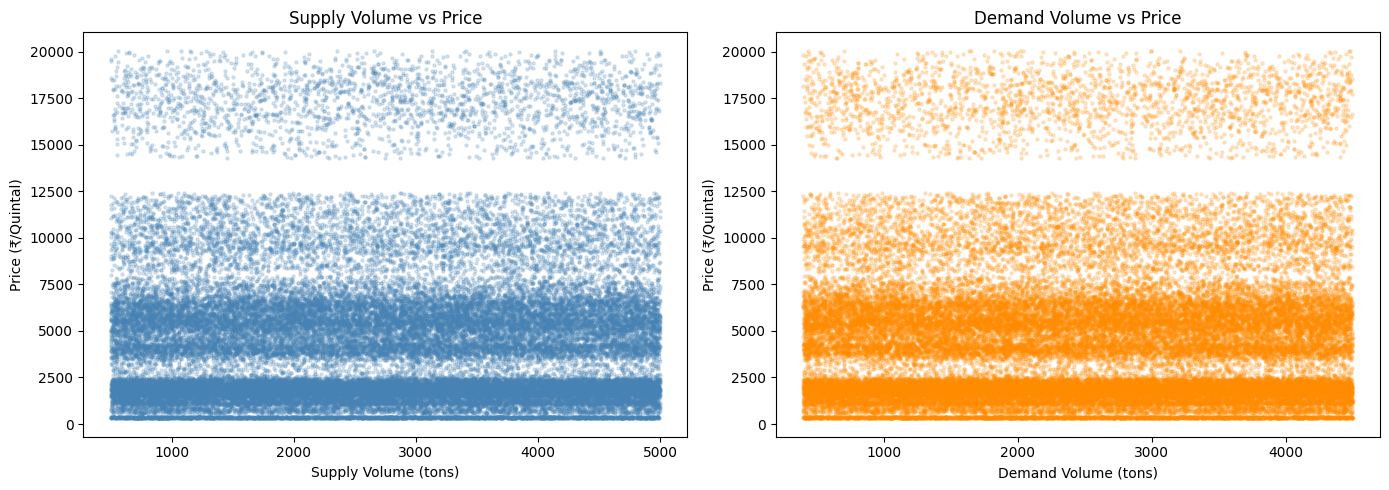

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Supply Volume (tons)'], df['Price/Quintal'], alpha=0.2, color='steelblue', s=5)
axes[0].set_title('Supply Volume vs Price')
axes[0].set_xlabel('Supply Volume (tons)')
axes[0].set_ylabel('Price (₹/Quintal)')

axes[1].scatter(df['Demand Volume (tons)'], df['Price/Quintal'], alpha=0.2, color='darkorange', s=5)
axes[1].set_title('Demand Volume vs Price')
axes[1].set_xlabel('Demand Volume (tons)')
axes[1].set_ylabel('Price (₹/Quintal)')

plt.tight_layout()
plt.show()


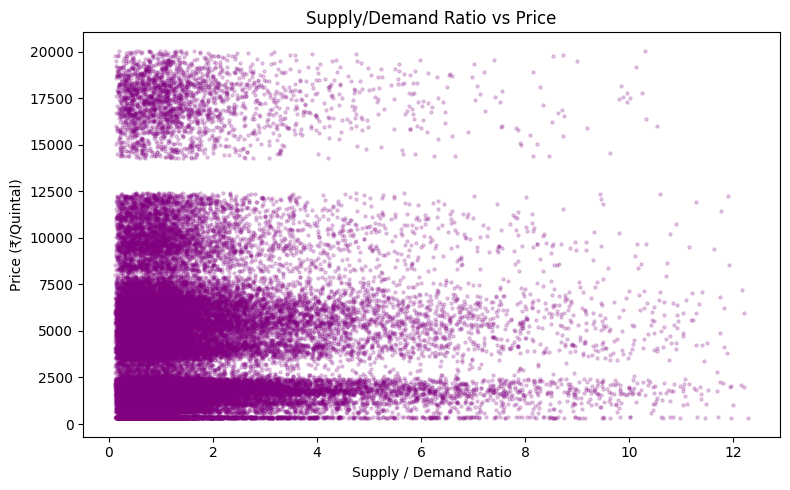

Correlation between Supply/Demand Ratio and Price: -0.0003


In [22]:
df['Supply_Demand_Ratio'] = df['Supply Volume (tons)'] / df['Demand Volume (tons)']

plt.figure(figsize=(8, 5))
plt.scatter(df['Supply_Demand_Ratio'], df['Price/Quintal'], alpha=0.2, color='purple', s=5)
plt.title('Supply/Demand Ratio vs Price')
plt.xlabel('Supply / Demand Ratio')
plt.ylabel('Price (₹/Quintal)')
plt.tight_layout()
plt.show()

ratio_corr = df['Supply_Demand_Ratio'].corr(df['Price/Quintal'])
print(f'Correlation between Supply/Demand Ratio and Price: {ratio_corr:.4f}')


##### NOTE: A correlation of -0.0003 is essentially zero. It means there is virtually no linear relationship between the Supply/Demand Ratio and Price globally across all crops.

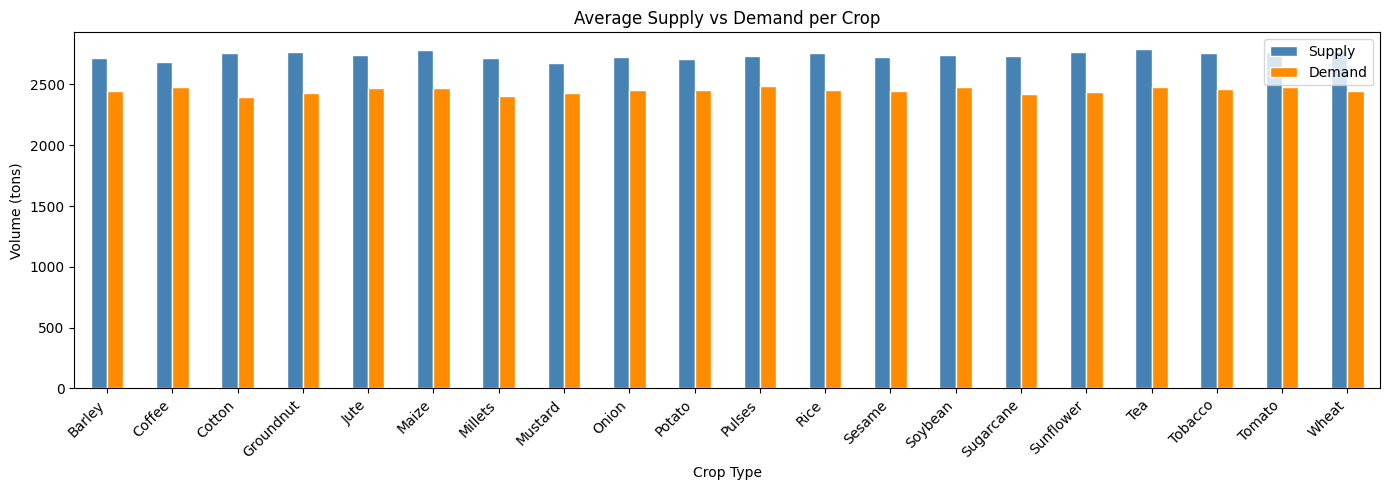

In [23]:
supply_demand = df.groupby('Crop Type')[['Supply Volume (tons)', 'Demand Volume (tons)']].mean()

supply_demand.plot(kind='bar', figsize=(14, 5), color=['steelblue', 'darkorange'], edgecolor='white')
plt.title('Average Supply vs Demand per Crop')
plt.xlabel('Crop Type')
plt.ylabel('Volume (tons)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Supply', 'Demand'])
plt.tight_layout()
plt.show()


- The **Supply/Demand Ratio** has near-zero global correlation with price (-0.0003), again due to the multi-crop mixing effect.
- However, the engineered `Supply_Demand_Ratio` feature is still worth retaining — within a crop context it will carry more signal and it is economically meaningful.
- Average Supply and Demand volumes are roughly balanced across all crops — no single crop dominates volume, confirming a well-distributed dataset.


In [24]:
print('EDA Summary')
print('=' * 55)
print(f'Most expensive crop   : {avg_price.idxmax()} (₹{avg_price.max():,.0f}/Quintal)')
print(f'Cheapest crop         : {avg_price.idxmin()} (₹{avg_price.min():,.0f}/Quintal)')
print(f'Most volatile crop    : {price_std.idxmax()} (std ₹{price_std.max():,.0f})')
print(f'Highest price state   : {state_price.idxmax()} (but diff is only ₹{state_price.max()-state_price.min():.1f})')
print(f'Best season for price : {season_price.idxmax()}')
print(f'SD Ratio vs Price corr: {ratio_corr:.4f} (near zero globally)')
print()
print('Key decisions for modelling:')
print('  1. Crop Type is the dominant feature — must be encoded')
print('  2. State/City have no predictive power — will be dropped')
print('  3. Season is meaningful — encode it')
print('  4. Supply/Demand ratio retained as engineered feature')
print('  5. Ensemble model needed to handle wide crop price range')


EDA Summary
Most expensive crop   : Tea (₹17,289/Quintal)
Cheapest crop         : Sugarcane (₹350/Quintal)
Most volatile crop    : Sesame (std ₹1,446)
Highest price state   : Tamil Nadu (but diff is only ₹16.0)
Best season for price : Zaid
SD Ratio vs Price corr: -0.0003 (near zero globally)

Key decisions for modelling:
  1. Crop Type is the dominant feature — must be encoded
  2. State/City have no predictive power — will be dropped
  3. Season is meaningful — encode it
  4. Supply/Demand ratio retained as engineered feature
  5. Ensemble model needed to handle wide crop price range


## Data Cleaning

In [25]:
total_null = df.isnull().sum()
print(total_null)


Date                               0
State                              0
City                               0
Crop Type                          0
Season                             0
Temperature (°C)                   0
Rainfall (mm)                      0
Supply Volume (tons)               0
Demand Volume (tons)               0
Transportation Cost (₹/Quintal)    0
Fertilizer Usage (kg/hectare)      0
Pest Infestation (0-1)             0
Market Competition (0-1)           0
Price/Quintal                      0
Month                              0
Supply_Demand_Ratio                0
dtype: int64


No NULL values exist in our Dataset

In [26]:
print(f'Duplicates: {df.duplicated().sum()}')
# number of duplicate values are also 0


Duplicates: 0


In [27]:
# Data Type
print(df.dtypes)


Date                               datetime64[ns]
State                                      object
City                                       object
Crop Type                                  object
Season                                     object
Temperature (°C)                          float64
Rainfall (mm)                             float64
Supply Volume (tons)                      float64
Demand Volume (tons)                      float64
Transportation Cost (₹/Quintal)           float64
Fertilizer Usage (kg/hectare)             float64
Pest Infestation (0-1)                    float64
Market Competition (0-1)                  float64
Price/Quintal                             float64
Month                                       int32
Supply_Demand_Ratio                       float64
dtype: object


#### Descriptive Statistics

In [28]:
df.describe()

,Date,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Transportation Cost (₹/Quintal),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1),Price/Quintal,Month,Supply_Demand_Ratio
count,48000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
mean,2023-12-16 10:00:00.000000256,27.506871,150.192671,2741.641435,2452.395630,274.877028,175.541043,0.499009,0.497963,4658.016332,6.500000,1.614093
min,2023-01-01 00:00:00,15.000000,0.000000,500.030000,400.040000,50.010000,50.010000,0.000000,0.000000,304.520000,1.000000,0.112835
25%,2023-06-23 12:00:00,21.200000,74.800000,1615.965000,1437.940000,162.195000,112.810000,0.250000,0.250000,1750.477500,3.750000,0.654714
50%,2023-12-16 12:00:00,27.500000,150.100000,2746.650000,2455.175000,275.430000,176.550000,0.500000,0.500000,3874.600000,6.500000,1.124198
75%,2024-06-08 12:00:00,33.700000,225.500000,3859.070000,3472.887500,386.805000,237.850000,0.750000,0.750000,6148.020000,9.250000,1.926010
max,2024-12-01 00:00:00,40.000000,300.000000,4999.950000,4499.820000,499.990000,300.000000,1.000000,1.000000,20057.200000,12.000000,12.286309
std,NaN,7.209975,86.828567,1299.022411,1179.123853,129.760062,72.284279,0.288935,0.288970,4032.598136,3.452088,1.579567


### Dropping low values features

In [29]:
# State and City shown in EDA to have near-zero price variation (~₹16 diff across all states)
# Dropping them as they add noise without predictive value

cols_to_drop = ['State', 'City']
df.drop(columns=cols_to_drop, inplace=True)

print(f'Dropped columns: {cols_to_drop}')
print(f'Shape after drop: {df.shape}')

Dropped columns: ['State', 'City']
Shape after drop: (48000, 14)


### Outlier Detection

In [30]:
# Check outliers using IQR method — per crop (not global)
# Global IQR would wrongly flag Tea/Coffee as outliers just because they are expensive

outlier_summary = []
for crop in df['Crop Type'].unique():
    crop_df = df[df['Crop Type'] == crop]['Price/Quintal']
    Q1 = crop_df.quantile(0.25)
    Q3 = crop_df.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((crop_df < lower) | (crop_df > upper)).sum()
    outlier_summary.append({'Crop': crop, 'Q1': round(Q1,1), 'Q3': round(Q3,1),
                             'Lower Bound': round(lower,1), 'Upper Bound': round(upper,1),
                             'Outliers': n_outliers})

outlier_df = pd.DataFrame(outlier_summary).set_index('Crop')
print(outlier_df)


                Q1       Q3  Lower Bound  Upper Bound  Outliers
Crop                                                           
Wheat       2046.5   2412.5       1497.4       2961.6         0
Rice        1849.0   2247.8       1250.8       2846.0         0
Maize       1612.8   1828.7       1289.0       2152.5         0
Cotton      5819.1   7140.7       3836.5       9123.2         0
Sugarcane    334.7    364.9        289.3        410.3         0
Pulses      4838.2   6001.8       3093.0       7747.0         0
Millets     1879.8   2199.8       1399.7       2679.9         0
Barley      1632.4   1954.3       1149.6       2437.1         0
Groundnut   4628.3   5948.4       2648.1       7928.6         0
Soybean     3767.3   4502.4       2664.6       5605.2         0
Jute        3359.7   3943.2       2484.6       4818.4         0
Tea        16315.3  18313.5      13318.0      21310.9         0
Coffee      9499.3  11017.2       7222.5      13294.0         0
Tobacco     5757.2   6892.0       4054.9

In [31]:
# Cap outliers at crop-level IQR bounds (Winsorization) instead of dropping rows
# This preserves all 48,000 records while removing extreme noise

df_clean = df.copy()

for crop in df_clean['Crop Type'].unique():
    mask = df_clean['Crop Type'] == crop
    crop_prices = df_clean.loc[mask, 'Price/Quintal']
    Q1 = crop_prices.quantile(0.25)
    Q3 = crop_prices.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean.loc[mask, 'Price/Quintal'] = crop_prices.clip(lower=lower, upper=upper)

print('Outlier capping (Winsorization) applied per crop')
print(f'Rows before: {len(df):,}  |  Rows after: {len(df_clean):,}  (no rows dropped)')
print()
print('Price range before:', round(df['Price/Quintal'].min(),2), '→', round(df['Price/Quintal'].max(),2))
print('Price range after :', round(df_clean['Price/Quintal'].min(),2), '→', round(df_clean['Price/Quintal'].max(),2))


Outlier capping (Winsorization) applied per crop
Rows before: 48,000  |  Rows after: 48,000  (no rows dropped)

Price range before: 304.52 → 20057.2
Price range after : 304.52 → 20057.2


- Global IQR would wrongly flag expensive crops like Tea and Coffee as outliers — **per-crop IQR is the correct approach**.
- **Winsorization (capping)** is chosen over dropping rows — it removes extreme noise while keeping all 48,000 records intact.
- All rows are preserved — important for time-series continuity in the Prophet model.

### Feature Engineering

In [32]:
#Time-based features
df_clean['Year']  = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Quarter'] = df_clean['Date'].dt.quarter

print('Time features added: Year, Month, Quarter')

Time features added: Year, Month, Quarter


In [33]:
df_clean['Supply_Demand_Ratio'] = (
    df_clean['Supply Volume (tons)'] / df_clean['Demand Volume (tons)']
).round(4)

print('Supply_Demand_Ratio engineered')
print(df_clean['Supply_Demand_Ratio'].describe())

Supply_Demand_Ratio engineered
count    48000.000000
mean         1.614093
std          1.579567
min          0.112800
25%          0.654700
50%          1.124200
75%          1.926025
max         12.286300
Name: Supply_Demand_Ratio, dtype: float64


In [34]:
# Crop-wise lag features — previous month price per crop
# Sort by Crop Type and Date first
df_clean = df_clean.sort_values(['Crop Type', 'Date']).reset_index(drop=True)

df_clean['Price_Lag1'] = df_clean.groupby('Crop Type')['Price/Quintal'].shift(1)
df_clean['Price_Lag3'] = df_clean.groupby('Crop Type')['Price/Quintal'].shift(3)

print('Lag features added: Price_Lag1, Price_Lag3')
print(f'NaN from lag features: {df_clean[["Price_Lag1","Price_Lag3"]].isnull().sum().to_dict()}')


Lag features added: Price_Lag1, Price_Lag3
NaN from lag features: {'Price_Lag1': 20, 'Price_Lag3': 60}


In [35]:
#  Rolling mean — 3-month rolling average price per crop
df_clean['Price_RollingMean3'] = (
    df_clean.groupby('Crop Type')['Price/Quintal']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    .round(2)
)

print('Rolling mean feature added: Price_RollingMean3')


Rolling mean feature added: Price_RollingMean3


In [36]:
# Show all new features
new_features = ['Year', 'Month', 'Quarter', 'Supply_Demand_Ratio',
                'Price_Lag1', 'Price_Lag3', 'Price_RollingMean3']

print('New engineered features:')
print(df_clean[new_features].sample(3))


New engineered features:
       Year  Month  Quarter  Supply_Demand_Ratio  Price_Lag1  Price_Lag3  \
6255   2024      3        1               0.5060     7757.83     5220.33   
9463   2024     11        4               0.3478     6329.99     3917.51   
17606  2023      9        3               1.6128     4030.41     5871.12   

       Price_RollingMean3  
6255              6987.60  
9463              5655.18  
17606             5459.71  


### Findings — Feature Engineering

| Feature | Type | Reason |
|---|---|---|
| `Year`, `Month`, `Quarter` | Time decomposition | Captures temporal trends for Prophet |
| `Supply_Demand_Ratio` | Ratio | Economically meaningful market pressure indicator |
| `Price_Lag1` | Lag feature | Previous month price — strong autocorrelation signal |
| `Price_Lag3` | Lag feature | 3-month ago price — captures quarterly cycles |
| `Price_RollingMean3` | Rolling stat | Smoothed trend signal, reduces noise |

- Lag features will have NaN for the first 1–3 records per crop — handled in Step 5.


### Encoding Categorical Variable

In [37]:
# Season encoding — ordinal makes agricultural sense
season_map = {'Rabi': 0, 'Kharif': 1, 'Zaid': 2, 'Post-Monsoon': 3}
df_clean['Season_Encoded'] = df_clean['Season'].map(season_map)

print('Season encoded:')
print(df_clean[['Season', 'Season_Encoded']].drop_duplicates().sort_values('Season_Encoded'))


Season encoded:
         Season  Season_Encoded
1          Rabi               0
0        Kharif               1
2          Zaid               2
3  Post-Monsoon               3


In [38]:
# Crop Type: Label Encoding (20 crops → 0 to 19)
# One-hot would create 20 columns — label encoding is sufficient for tree-based models
crop_categories = sorted(df_clean['Crop Type'].unique())
crop_map = {crop: i for i, crop in enumerate(crop_categories)}
df_clean['Crop_Encoded'] = df_clean['Crop Type'].map(crop_map)

print('Crop Type encoded:')
for crop, code in crop_map.items():
    print(f'  {code:2d} → {crop}')


Crop Type encoded:
   0 → Barley
   1 → Coffee
   2 → Cotton
   3 → Groundnut
   4 → Jute
   5 → Maize
   6 → Millets
   7 → Mustard
   8 → Onion
   9 → Potato
  10 → Pulses
  11 → Rice
  12 → Sesame
  13 → Soybean
  14 → Sugarcane
  15 → Sunflower
  16 → Tea
  17 → Tobacco
  18 → Tomato
  19 → Wheat


### Handle NaN from Lag Features

In [39]:
print('NaN count before handling:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Fill lag NaNs with the crop's own mean price — safe fallback
df_clean['Price_Lag1'] = df_clean.groupby('Crop Type')['Price_Lag1'].transform(
    lambda x: x.fillna(x.mean())
)
df_clean['Price_Lag3'] = df_clean.groupby('Crop Type')['Price_Lag3'].transform(
    lambda x: x.fillna(x.mean())
)

print()
print('NaN count after handling:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0] if df_clean.isnull().sum().any() else 'No NaN values remaining')


NaN count before handling:
Price_Lag1    20
Price_Lag3    60
dtype: int64

NaN count after handling:
No NaN values remaining


In [40]:
# Final feature set that will be used for model training
FEATURES = [
    'Crop_Encoded', 'Season_Encoded', 'Month', 'Quarter', 'Year',
    'Temperature (°C)', 'Rainfall (mm)',
    'Supply Volume (tons)', 'Demand Volume (tons)',
    'Supply_Demand_Ratio',
    'Transportation Cost (₹/Quintal)',
    'Fertilizer Usage (kg/hectare)',
    'Pest Infestation (0-1)', 'Market Competition (0-1)',
    'Price_Lag1', 'Price_Lag3', 'Price_RollingMean3'
]

TARGET = 'Price/Quintal'

print('Features for model training:')
for f in FEATURES:
    print(f'  - {f}')
print()
print(f'Target: {TARGET}')
print(f'Total features: {len(FEATURES)}')


Features for model training:
  - Crop_Encoded
  - Season_Encoded
  - Month
  - Quarter
  - Year
  - Temperature (°C)
  - Rainfall (mm)
  - Supply Volume (tons)
  - Demand Volume (tons)
  - Supply_Demand_Ratio
  - Transportation Cost (₹/Quintal)
  - Fertilizer Usage (kg/hectare)
  - Pest Infestation (0-1)
  - Market Competition (0-1)
  - Price_Lag1
  - Price_Lag3
  - Price_RollingMean3

Target: Price/Quintal
Total features: 17


In [41]:
df_clean[FEATURES + [TARGET]].head(5)


,Crop_Encoded,Season_Encoded,Month,Quarter,Year,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Supply_Demand_Ratio,Transportation Cost (₹/Quintal),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1),Price_Lag1,Price_Lag3,Price_RollingMean3,Price/Quintal
0,0,1,1,1,2023,34.2,234.4,3422.54,1766.89,1.9370,95.26,113.11,0.96,0.31,1783.299783,1783.329441,1755.82,1755.82
1,0,0,1,1,2023,28.3,198.4,4690.36,4381.28,1.0705,193.48,120.36,0.76,0.10,1755.820000,1783.329441,1571.66,1387.51
2,0,2,1,1,2023,17.9,62.5,4264.75,1160.19,3.6759,498.76,61.06,0.71,0.60,1387.510000,1783.329441,1767.52,2159.23
3,0,3,1,1,2023,24.4,83.7,1726.91,3452.41,0.5002,208.89,156.24,0.37,0.23,2159.230000,1755.820000,1752.97,1712.16
4,0,1,1,1,2023,16.1,30.0,1879.13,1473.17,1.2756,252.77,111.16,0.73,0.67,1712.160000,1387.510000,1918.56,1884.28


### Export Clean Dataset
- Saving clean Dataset

In [42]:
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
OUTPUT_PATH = NOTEBOOK_DIR.parent / 'database' / 'crop_price_cleaned.csv'


In [43]:
# Save cleaned dataset
df_clean.to_csv(OUTPUT_PATH, index=False)

print(f'  {OUTPUT_PATH}')
print(f'File contains {len(df_clean):,} rows and {len(df_clean.columns)} columns')


  D:\Capstrone Project\backend\database\crop_price_cleaned.csv
File contains 48,000 rows and 21 columns


In [44]:
! pip install prophet